Noah Barron  
April 20, 2026  
Intro to Data Science

# FP: Typing Test Triumphs

Loading in the typing data:

In [39]:
import pandas as pd

typing_df = pd.read_csv("typing_4-19-26.csv")

Cleaning the dataset:

(Dropping some columns & replacing the ids)

In [40]:
remove_cols = ["charStats", "mode", "mode2", "quoteLength", "restartCount", "afkDuration",
               "incompleteTestSeconds", "punctuation", "numbers", "language", "funbox",
               "difficulty", "lazyMode", "blindMode", "bailedOut", "tags", "testDuration",
               "timestamp"]

typing_df = typing_df.drop(columns=remove_cols)

# replacing the ids with numbers 0 to n:
for i in range(typing_df["_id"].size):
    typing_df.loc[i, "_id"] = i

# setting the ids as the index:
typing_df.set_index("_id")

,isPb,wpm,acc,rawWpm,consistency
_id,,,,,
0,NaN,72.81,95.92,77.41,76.54
1,NaN,64.40,92.23,73.40,69.19
2,NaN,75.61,97.24,79.21,77.48
3,NaN,73.20,96.65,77.60,75.97
4,NaN,66.60,96.66,71.20,72.29
...,...,...,...,...,...
102,True,63.60,95.04,72.60,72.11
103,True,50.80,93.35,63.21,67.88
104,True,62.00,95.43,70.00,71.29


Next, we'll place the values for whether the test was taken at night, along with on what day.

In [41]:
night_list = ["true", "false", "true", "false", "true", "false", "true", "false", "true", "false", "true", "false", "true",
              "true", "false", "true", "false", "true", "false", "false", "true", "false", "true", "false", "true", "false",
              "true", "false", "true", "false", "true", "false", "true", "false", "true", "true", "false", "false", "true",
              "false", "true", "false", "true", "false", "true", "false", "true", "false", "true", "true", "false", "true",
              "false", "true", "false", "true", "false", "true", "false", "true", "false", "true", "false", "true", "false",
              "false", "true", "false", "true", "false", "true", "false", "true", "false", "true", "true", "true", "true",
              "true", "false", "true", "false", "true", "false", "true","false", "true", "false", "true", "false", "false",
              "true", "true", "true", "false", "true", "false", "true", "false", "true", "false", "true", "false", "true",
              "true", "false", "true"]

typing_df.insert(1, "night", night_list)

date_list = ["2-9-26", "2-10-26", "2-10-26", "2-11-26", "2-11-26", "2-12-26", "2-12-26", "2-13-26", "2-13-26", "2-14-26",
             "2-14-26", "2-15-26", "2-15-26", "2-16-26", "2-17-26", "2-17-26", "2-18-26", "2-18-26", "2-19-26", "2-20-26",
             "2-20-26", "2-21-26", "2-21-26", "2-22-26", "2-22-26", "2-23-26", "2-23-26", "2-24-26", "2-24-26", "2-25-26",
             "2-25-26", "2-26-26", "2-26-26", "2-27-26", "2-27-26", "2-28-26", "3-1-26", "3-2-26", "3-2-26", "3-3-26",
             "3-3-26", "3-4-26", "3-4-26", "3-5-26", "3-5-26", "3-6-26", "3-6-26", "3-7-26", "3-7-26", "3-8-26", "3-9-26",
             "3-9-26", "3-10-26", "3-10-26", "3-11-26", "3-11-26", "3-12-26", "3-12-26", "3-13-26", "3-13-26", "3-14-26",
             "3-14-26", "3-15-26", "3-15-26", "3-16-26", "3-17-26", "3-17-26", "3-18-26", "3-18-26", "3-19-26", "3-19-26",
             "3-21-26", "3-21-26", "3-22-26", "3-22-26", "3-23-26", "3-24-26", "3-25-26", "3-26-26", "3-27-26", "3-27-26",
             "3-28-26", "3-28-26", "3-29-26", "3-29-26", "3-30-26", "3-30-26", "3-31-26", "4-1-26", "4-2-26", "4-7-26",
             "4-7-26", "4-8-26", "4-9-26", "4-10-26", "4-12-26", "4-13-26", "4-13-26", "4-14-26", "4-14-26", "4-15-26",
             "4-15-26", "4-16-26", "4-16-26", "4-17-26", "4-19-26", "4-19-26"]

typing_df.insert(1, "date", date_list)

Now we're going to compare our typing data during the day vs the night over time using a grouped bar chart.

In [42]:
import matplotlib.pyplot as plt
import numpy as np

bar_width = 0.2
num_months = 3
month_names = ["Feb", "Mar", "Apr"]
starts_and_ends = [0, 36, 36, 88, 88, 107] # indexes
morning_wpm_avg = []
night_wpm_avg = []
morning_acc_avg = []
night_acc_avg = []

# split into morning/day, then into wpm/acc, for each of the time periods
for i in range(num_months):
    start = starts_and_ends[i * 2]
    end = starts_and_ends[(i * 2) + 1]

    month_slice = typing_df[start:end]
    grouped_by_time = month_slice.groupby("night")
    morning_df = grouped_by_time.get_group("false")
    night_df = grouped_by_time.get_group("true")

    morning_wpm_avg.append(morning_df["wpm"].mean())
    night_wpm_avg.append(night_df["wpm"].mean())
    morning_acc_avg.append(morning_df["acc"].mean())
    night_acc_avg.append(night_df["acc"].mean())

Now let's actually plot the data.

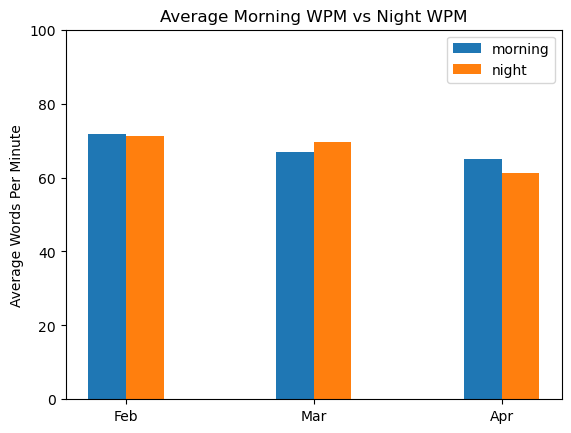

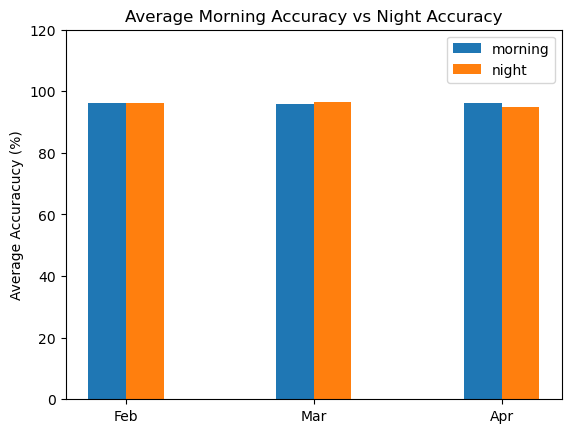

In [43]:
# plotting wpm averages:
plt.figure()
plt.bar(month_names, height=morning_wpm_avg, width=-bar_width, align="edge", label="morning")
plt.bar(month_names, height=night_wpm_avg, width=bar_width, align="edge", label="night")
plt.ylim([0, 100])
plt.legend(loc="upper right")
plt.title("Average Morning WPM vs Night WPM")
plt.ylabel("Average Words Per Minute")
plt.show()

# plotting acc averages:
plt.figure()
plt.bar(month_names, height=morning_acc_avg, width=-bar_width, align="edge", label="morning")
plt.bar(month_names, height=night_acc_avg, width=bar_width, align="edge", label="night")
plt.ylim([0, 120])
plt.legend(loc="upper right")
plt.title("Average Morning Accuracy vs Night Accuracy")
plt.ylabel("Average Accuracucy (%)")
plt.show()

I'm pretty shooketh, because I expected an actual difference between the day and the night data.

### Hypothesis testing time!

Let's answer this question:  
*Is the wpm from April (so far) greater than the wpm from February?*

$\mu_1$ = February's WPM  
$\mu_2$ = April's WPM

Step 1:  
$H_0$: $\mu_1$ $\geq$ $\mu_2$  
$H_1$: $\mu_1$ < $\mu_2$

Step 2:  
$\alpha$ = 0.001

Step 3:  
This is a two sample test, since there is data from two separate months that we are comparing. It is one tailed, since we are checking if the wpm from one month is more than another's. Lastly, it is independent, because the groups happened at different moments but with the same variables, so they cannot be paired.

In [44]:
import scipy.stats as stats

february_wpm = typing_df[0:36]["wpm"].to_list()
april_wpm = typing_df[88:107]["wpm"].to_list()

t_computed, p_val = stats.ttest_ind(february_wpm, april_wpm)
p_val /= 2 # because it's one-tailed
print("Step 3 (Cont.):")
print("t computed:", t_computed, "p value:", p_val)

print()
print("Step 4:\nIf our p-value is less than our alpha, we reject the null hypothesis.")
print()
print("Step 5:")
alpha = 0.001
if p_val < alpha:
    print("We reject the null hypothesis.")
else:
    print("We do NOT reject the null hypothesis.")

Step 3 (Cont.):
t computed: 5.442388155434001 p value: 6.869439628604203e-07

Step 4:
If our p-value is less than our alpha, we reject the null hypothesis.

Step 5:
We reject the null hypothesis.


Since we are rejecting the null hypothesis that $\mu_1$ $\geq$ $\mu_2$, we find that there is statistical evidence that $\mu_1$ < $\mu_2$ (April's WPM is greater than February's) at a 0.001 alpha value.